In [ ]:
import os
import multiprocessing

# Number of CPU cores available
cpu_count = os.cpu_count()  # or use multiprocessing.cpu_count()
print(f"Number of CPU cores: {cpu_count}")

Plot saved as 'MERIT_CLRH_subbasin_area_cdf_plot.png'


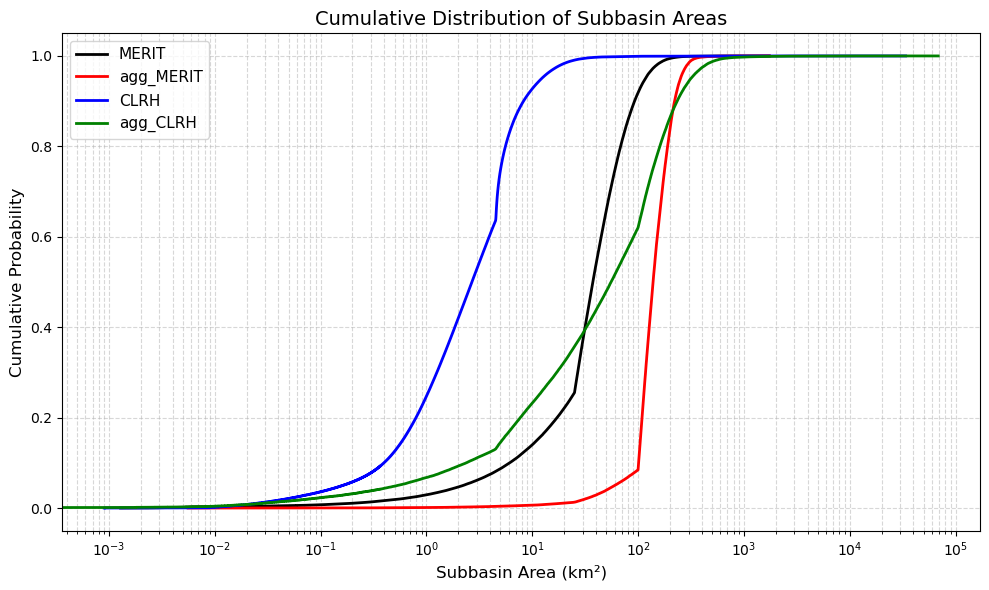

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# List of file paths
file_paths = [
    'D:/Zelalem/MERIT/Newagg/sub_merit_cantrans_subbasins.shp',
    'D:/Zelalem/MERIT/Newagg/agg_MERIT_CanTrans_subbasins.shp',
    'D:/Zelalem/CLRH_Basin/merged_finalcat_info_v1-0.gpkg',
    'D:/Zelalem/CLRH_Basin/BasinMaker/merged_finalcat_info_v1-0.gpkg'
]

# Area column names
area_columns = [
    "unitarea",   # MERIT: already in km²
    "unitarea",   # agg_MERIT: already in km²
    "BasArea",    # CLRH: in m² → convert
    "BasArea"     # BasinMaker (agg_CL RH): in m² → convert
]

# Colors and labels
colors = ['black', 'red', 'blue', 'green']
labels = ['MERIT', 'agg_MERIT', 'CLRH', 'agg_CLRH']

plt.figure(figsize=(10, 6))

for path, area_col, color, label in zip(file_paths, area_columns, colors, labels):
    # Read file
    gdf = gpd.read_file(path)

    # Confirm area column exists
    if area_col not in gdf.columns:
        raise ValueError(f"Area column '{area_col}' not found in {path}")

    # Extract area and clean
    area = gdf[area_col].dropna()

    # Convert units: BasArea is in m², unitarea is in km²
    if 'BasArea' in area_col:
        area = area / 1_000_000  # m² → km²
    # else: unitarea is already in km² → do nothing

    # Skip if no valid areas
    if len(area) == 0:
        print(f"Warning: No valid area data in {path}")
        continue

    # Sort and compute CDF
    area_sorted = np.sort(area)
    cdf = np.arange(1, len(area_sorted) + 1) / len(area_sorted)

    # Plot
    plt.plot(area_sorted, cdf, label=label, color=color, linewidth=2)

# Styling
plt.xscale('log')
plt.xlabel("Subbasin Area (km²)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.title("Cumulative Distribution of Subbasin Areas", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

# Save
output_file = "MERIT_CLRH_subbasin_area_cdf_plot.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"Plot saved as '{output_file}'")

plt.show()

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Optional, Dict, Any


def plot_log_scatter_complete_only(
    shapefile_path: str,
    area_cols: List[str],
    y_cols: List[str],
    colors: List[str],
    legend_labels: List[str],
    nodata_values: List[Any] = [-9999, -999, None],
    filter_dict: Optional[Dict[str, Any]] = None
):
    """
    Log-log scatter plot that keeps ONLY stations with valid area in ALL columns.
    """
    # --- Read shapefile ---
    gdf = gpd.read_file(shapefile_path)
    print(f"Total stations loaded: {len(gdf)}")

    # --- 1. Apply user-defined filter (e.g., status == "A") ---
    if filter_dict is not None:
        for col, val in filter_dict.items():
            if col not in gdf.columns:
                raise KeyError(f"Column '{col}' not found for filtering. Available: {list(gdf.columns)}")
            initial = len(gdf)
            gdf = gdf[gdf[col] == val].copy()
            print(f"After filtering {col} == '{val}': {initial} → {len(gdf)} stations")

    if gdf.empty:
        raise ValueError("No stations remain after initial filtering.")

    # --- 2. Replace nodata with NaN ---
    for col in area_cols:
        gdf[col] = gdf[col].replace(nodata_values, np.nan)

    # --- 3. Drop rows with <= 0 or NaN in ANY of the area columns ---
    print(f"Requiring valid (>0 and not NaN) values in ALL of: {area_cols}")
    initial_count = len(gdf)

    # Create mask: keep only rows where ALL area_cols are positive and finite
    valid_mask = np.ones(len(gdf), dtype=bool)
    for col in area_cols:
        valid_mask &= gdf[col] > 0
        valid_mask &= gdf[col].notna()

    gdf = gdf[valid_mask].copy()
    print(f"After removing incomplete/invalid stations: {initial_count} → {len(gdf)} stations kept")
    
    if gdf.empty:
        raise ValueError("No stations have valid drainage area in all datasets!")

    # --- 4. Compute log10 ---
    log_cols = {}
    for col in area_cols:
        log_col = f"log_{col}"
        gdf[log_col] = np.log10(gdf[col])
        log_cols[col] = log_col

    x_log_col = "log_Area_km2"  # WSC reference area

    # --- Plotting ---
    plt.figure(figsize=(8.5, 8.5))

    for y_col, color, label in zip(y_cols, colors, legend_labels):
        y_log_col = log_cols[y_col]
        df_plot = gdf[[x_log_col, y_log_col]]  # already clean, no need to dropna again

        plt.scatter(
            df_plot[x_log_col],
            df_plot[y_log_col],
            color=color,
            alpha=0.8,
            s=50,
            edgecolors="white",
            linewidth=0.8,
            label=f"{label} (n={len(df_plot)})"
        )

    # --- 1:1 line ---
    all_logs = gdf[[x_log_col] + [log_cols[y] for y in y_cols]].values
    min_val, max_val = all_logs.min(), all_logs.max()
    pad = 0.05 * (max_val - min_val)
    plt.plot([min_val-pad, max_val+pad], [min_val-pad, max_val+pad],
             'k--', lw=1.8, label='1:1 line', zorder=0)

    # --- Aesthetics ---
    plt.xlabel("log₁₀(Drainage Area – WSC [km²])")
    plt.ylabel("log₁₀(Drainage Area – HydroFABRIC [km²])")
    plt.title(f"Log–Log Comparison – Complete Cases Only\n"
              f"Only stations with valid area in all sources")
    plt.legend(title="Dataset", loc="upper left", frameon=True)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    return gdf  # optional: return filtered GeoDataFrame for further use

Total stations loaded: 7527
After filtering Status == 'active': 7527 → 2778 stations
Requiring valid (>0 and not NaN) values in ALL of: ['Area_km2', 'MERIT_DA', 'CLRH_DA']
After removing incomplete/invalid stations: 2778 → 2629 stations kept


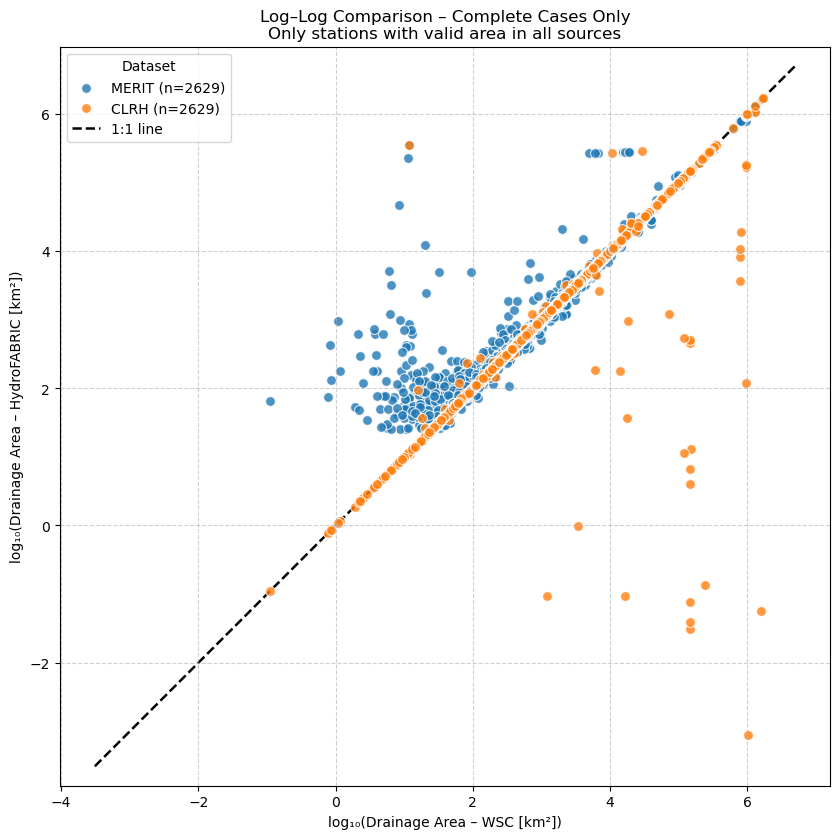

In [5]:
# -------------------------------------------------------------------------
# Example: Only active ("A") stations AND present in WSC + MERIT + CLRH
# -------------------------------------------------------------------------
filtered_gdf = plot_log_scatter_complete_only(
    shapefile_path="D:/Zelalem/WSC/Merged_MDA_ADP_Stations.shp",
    area_cols=["Area_km2", "MERIT_DA", "CLRH_DA"],
    y_cols=["MERIT_DA", "CLRH_DA"],
    colors=["#1f77b4", "#ff7f0e"],
    legend_labels=["MERIT", "CLRH"],
    nodata_values=[-9999, -999, -99.99, None],
    filter_dict={"Status": "active"}        # ← This is the new filter!
    # filter_dict={"status": "A", "Flag": 0}  # multiple conditions example
)